## **Modelos de Machine Learning — Prediccion de precio de propiedades**

## Librerias

In [1]:
#uv add scikit-learn xgboost
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 4)

RANDOM_STATE = 42
DEVELOPER = "Ivan Camilo Rosales"

## **Lectura del archivo base**

In [2]:
RUTA_FUENTES = Path("../fuentes")
RUTA_CSV = RUTA_FUENTES / "co_transacciones_habi.csv"

df_csv = pd.read_csv(RUTA_CSV)
print(f"Filas: {len(df_csv):,}  |  Columnas: {df_csv.shape[1]}")
df_csv.head()

Filas: 45,901  |  Columnas: 11


,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado
0,CO038760,SANTA MARTA,Casa,109.6,2,3,416700000.0,6.235260,-75.549642,2024-02-28,publicada
1,CO043235,SANTA MARTA,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
2,C1023947,VALLEDUPAR,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
3,CO004450,MEDELLIN,Casa,176.7,2,2,200000000.0,6.198647,-75.559899,2024-04-10,comprada
4,CO025197,BOGOTA,Apartamento,77.8,2,2,159700000.0,4.660761,-74.049764,2024-10-11,publicada


## **Transformaciones**

In [3]:
MAPA_CIUDADES = {
    "BOGOTA": "Bogota",
    "Bogota": "Bogota",
    "Bogota D.C.": "Bogota",
    "Bogotá": "Bogota",
    "MEDELLIN": "Medellin",
    "Medellin": "Medellin",
    "Medellín": "Medellin",
    "Cali": "Cali",
    "Santiago de Cali": "Cali",
    "Barranquilla": "Barranquilla",
    "B/quilla": "Barranquilla",
}

df = df_csv.copy()
df["ciudad"] = df["ciudad"].str.strip().map(MAPA_CIUDADES).fillna(df["ciudad"].str.strip().str.title())
df["tipo"] = df["tipo"].str.strip().str.title()
df["estado"] = df["estado"].str.strip().str.lower()

columnas_numericas = ["area_m2", "alcobas", "banos", "precio_cop", "lat", "lon"]
for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df.head()

,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado
0,CO038760,Santa Marta,Casa,109.6,2,3,416700000.0,6.235260,-75.549642,2024-02-28,publicada
1,CO043235,Santa Marta,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
2,C1023947,Valledupar,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
3,CO004450,Medellin,Casa,176.7,2,2,200000000.0,6.198647,-75.559899,2024-04-10,comprada
4,CO025197,Bogota,Apartamento,77.8,2,2,159700000.0,4.660761,-74.049764,2024-10-11,publicada


In [ ]:
# Filas sin precio_cop no sirven para entrenar
df = df[df["precio_cop"].notna()].copy()

# Duplicados por id nos quedamos con la primera ocurrencia
df = df.drop_duplicates(subset="id", keep="first")

print(f"Filas despues de limpieza: {len(df):,}")

Filas despues de limpieza: 44,641


## **Feature engineering**

In [ ]:
PRECIO_MINIMO = 10_000_000

df["banos_por_alcoba"] = df["banos"] / df["alcobas"]
df["area_por_alcoba"] = df["area_m2"] / df["alcobas"]
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["trimestre"] = df["fecha"].dt.quarter
df["dia_semana"] = ((df["fecha"].dt.dayofweek + 1) % 7) + 1  # 1=domingo ... 7=sabado

df = df[df["precio_cop"] >= PRECIO_MINIMO].copy()
print(f"Filas tras filtro de precio minimo ({PRECIO_MINIMO:,}): {len(df):,}")

Filas tras filtro de precio minimo (10,000,000): 43,970


### Features y variable objetivo

In [6]:
FEATURES_NUM = [
    "area_m2", "alcobas", "banos", "lat", "lon",
    "banos_por_alcoba", "area_por_alcoba",
    "anio", "mes", "trimestre", "dia_semana",
]
FEATURES_CAT = ["ciudad", "tipo", "estado"]
TARGET = "precio_cop"

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[TARGET]

### Separacion train / test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 35,176  |  Test: 8,794


### Preprocesamiento de features

In [8]:
def construir_preprocesador(features_num, features_cat):
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconocido")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipeline, features_num),
        ("cat", cat_pipeline, features_cat),
    ])

In [9]:
preprocesador = construir_preprocesador(FEATURES_NUM, FEATURES_CAT)
X_train_proc = preprocesador.fit_transform(X_train)
X_test_proc = preprocesador.transform(X_test)

print(f"X_train_proc: {X_train_proc.shape}  |  X_test_proc: {X_test_proc.shape}")

X_train_proc: (35176, 24)  |  X_test_proc: (8794, 24)


## **Diseno de modelos machine learning**

In [10]:
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


def validacion_cruzada(model, X, y, cv=5, random_state=RANDOM_STATE):
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    metricas_folds = {"MAE": [], "RMSE": [], "R2": [], "MAPE": []}

    X = np.asarray(X)
    for train_idx, val_idx in kf.split(X):
        modelo_fold = clone(model)
        modelo_fold.fit(X[train_idx], y.iloc[train_idx])
        y_pred = modelo_fold.predict(X[val_idx])
        for metrica, valor in calcular_metricas(y.iloc[val_idx], y_pred).items():
            metricas_folds[metrica].append(valor)

    return {metrica: np.mean(valores) for metrica, valores in metricas_folds.items()}

In [11]:
def evaluar_modelo(
    model,
    name_model: str,
    developer: str,
    X_train, X_test, y_train, y_test,
    cv_folds: int = 5,
):
    """Corre CV sobre train y evalua el modelo (ya entrenado) en train/test."""
    logger.info(f"Evaluando modelo: {name_model} (desarrollado por {developer})")

    metricas_cv = validacion_cruzada(model, X_train, y_train, cv=cv_folds)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metricas_train = calcular_metricas(y_train, y_train_pred)
    metricas_test = calcular_metricas(y_test, y_test_pred)

    print(f"\n{'=' * 64}\nModelo: {name_model}\n{'=' * 64}")
    print(f"CV ({cv_folds}-fold) -> MAE={metricas_cv['MAE']:>13,.0f}  RMSE={metricas_cv['RMSE']:>13,.0f}  R2={metricas_cv['R2']:.4f}  MAPE={metricas_cv['MAPE']:.2f}%")
    print(f"Train         -> MAE={metricas_train['MAE']:>13,.0f}  RMSE={metricas_train['RMSE']:>13,.0f}  R2={metricas_train['R2']:.4f}  MAPE={metricas_train['MAPE']:.2f}%")
    print(f"Test          -> MAE={metricas_test['MAE']:>13,.0f}  RMSE={metricas_test['RMSE']:>13,.0f}  R2={metricas_test['R2']:.4f}  MAPE={metricas_test['MAPE']:.2f}%")

    return {"cv": metricas_cv, "train": metricas_train, "test": metricas_test}

In [12]:
resultados = {}

## **Modelo Regresion Lineal**

In [13]:
modelo_regresion_lineal = LinearRegression(fit_intercept=True)
modelo_regresion_lineal.fit(X_train_proc, y_train)
resultados["regresion_lineal"] = evaluar_modelo(
    model=modelo_regresion_lineal,
    name_model="regresion_lineal",
    developer=DEVELOPER,
    X_train=X_train_proc,
    X_test=X_test_proc,
    y_train=y_train,
    y_test=y_test,
)

INFO:__main__:Evaluando modelo: regresion_lineal (desarrollado por Ivan Camilo Rosales)



Modelo: regresion_lineal
CV (5-fold) -> MAE=   25,904,259  RMSE=   34,045,763  R2=0.7657  MAPE=17.01%
Train         -> MAE=   25,875,526  RMSE=   33,982,503  R2=0.7667  MAPE=17.00%
Test          -> MAE=   25,999,951  RMSE=   34,541,639  R2=0.7642  MAPE=17.01%


Los resultados muestran un rendimiento consistente entre train (R2=0.7667) y test (R2=0.7642), con una diferencia minima que indica una buena generalizacion, sin overfitting. El MAPE de 17.01% en test es el mas alto de los cuatro modelos

## **Modelo Arbol de Decision**

In [14]:
modelo_arbol_decision = DecisionTreeRegressor(
    max_depth=10, min_samples_split=20, min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
modelo_arbol_decision.fit(X_train_proc, y_train)
resultados["arbol_decision"] = evaluar_modelo(
    model=modelo_arbol_decision,
    name_model="arbol_decision",
    developer=DEVELOPER,
    X_train=X_train_proc,
    X_test=X_test_proc,
    y_train=y_train,
    y_test=y_test,
)

INFO:__main__:Evaluando modelo: arbol_decision (desarrollado por Ivan Camilo Rosales)



Modelo: arbol_decision
CV (5-fold) -> MAE=   25,834,230  RMSE=   35,056,462  R2=0.7516  MAPE=15.82%
Train         -> MAE=   23,022,723  RMSE=   30,996,592  R2=0.8059  MAPE=14.12%
Test          -> MAE=   25,647,740  RMSE=   35,117,859  R2=0.7562  MAPE=15.68%


El arbol de decision mejora el MAPE frente a la regresion lineal (15.68% vs 17.01% en test), gracias a su capacidad de capturar interacciones no lineales. Sin embargo, aparece una brecha entre train (R2=0.8059) y test (R2=0.7562) de casi 0.05, lo que sugiere un leve sobreajuste pese a la regularizacion aplicada (`max_depth=10`, `min_samples_leaf=5`). Aun asi, generaliza de forma aceptable y supera al modelo lineal en todas las metricas de test.

## **Modelo Random Forest**

In [15]:
modelo_random_forest = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=3,
    n_jobs=-1, random_state=RANDOM_STATE,
)
modelo_random_forest.fit(X_train_proc, y_train)
resultados["random_forest"] = evaluar_modelo(
    model=modelo_random_forest,
    name_model="random_forest",
    developer=DEVELOPER,
    X_train=X_train_proc,
    X_test=X_test_proc,
    y_train=y_train,
    y_test=y_test,
)

INFO:__main__:Evaluando modelo: random_forest (desarrollado por Ivan Camilo Rosales)



Modelo: random_forest
CV (5-fold) -> MAE=   24,987,976  RMSE=   33,751,636  R2=0.7697  MAPE=15.35%
Train         -> MAE=   17,452,492  RMSE=   23,734,969  R2=0.8862  MAPE=10.73%
Test          -> MAE=   24,927,029  RMSE=   34,096,202  R2=0.7702  MAPE=15.25%


Random Forest obtiene el mejor MAE de test entre los modelos "clasicos" (24,927,029) y un R2 de 0.7702, ademas de un MAPE de 15.25%. El costo es una brecha mas amplia entre train (R2=0.8862) y test (R2=0.7702): el ensamble de 100 arboles memoriza mas patrones del conjunto de entrenamiento de lo que logra transferir a datos nuevos. Aun con ese sobreajuste, es el segundo mejor modelo en el conjunto de prueba.

## **Modelo XGBoost**

In [16]:
modelo_xgboost = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
)
modelo_xgboost.fit(X_train_proc, y_train)
resultados["xgboost"] = evaluar_modelo(
    model=modelo_xgboost,
    name_model="xgboost",
    developer=DEVELOPER,
    X_train=X_train_proc,
    X_test=X_test_proc,
    y_train=y_train,
    y_test=y_test,
)

INFO:__main__:Evaluando modelo: xgboost (desarrollado por Ivan Camilo Rosales)



Modelo: xgboost
CV (5-fold) -> MAE=   24,938,546  RMSE=   33,651,788  R2=0.7711  MAPE=15.35%
Train         -> MAE=   21,659,339  RMSE=   28,664,235  R2=0.8340  MAPE=13.65%
Test          -> MAE=   24,879,612  RMSE=   34,045,475  R2=0.7709  MAPE=15.25%


XGBoost logra el mejor desempeno en test de los cuatro modelos: R2=0.7709, MAE=24,879,612 y MAPE=15.25% (empatado con Random Forest). A diferencia de Random Forest, su brecha train/test es mas pequena (R2 train=0.8340 vs test=0.7709, diferencia de ~0.06 contra ~0.12 de Random Forest), lo que indica un mejor balance sesgo-varianza gracias al `learning_rate=0.1` y al submuestreo (`subsample=0.8`, `colsample_bytree=0.8`). Es el modelo con mejor relacion entre desempeno y capacidad de generalizacion.

## **Comparacion de modelos**

In [17]:
tabla_comparacion = pd.DataFrame({
    nombre: valores["test"] for nombre, valores in resultados.items()
}).T.sort_values("R2", ascending=False)
tabla_comparacion

,MAE,RMSE,R2,MAPE
xgboost,2.487961e+07,3.404547e+07,0.770903,15.249904
random_forest,2.492703e+07,3.409620e+07,0.770219,15.248260
regresion_lineal,2.599995e+07,3.454164e+07,0.764176,17.007133
arbol_decision,2.564774e+07,3.511786e+07,0.756243,15.680922


In [ ]:
modelos_por_nombre = {
    "regresion_lineal": modelo_regresion_lineal,
    "arbol_decision": modelo_arbol_decision,
    "random_forest": modelo_random_forest,
    "xgboost": modelo_xgboost,
}


mejor_nombre = tabla_comparacion["R2"].idxmax()
mejor_modelo = modelos_por_nombre[mejor_nombre]
print(f"Mejor modelo: {mejor_nombre}  (R2 test = {tabla_comparacion.loc[mejor_nombre, 'R2']:.4f})")

Mejor modelo: xgboost  (R2 test = 0.7709)


## **Conclusiones finales**

Comparando los cuatro modelos sobre el conjunto de test:

| Modelo             | MAE test    | RMSE test   | R2 test | MAPE test |
|---------------------|------------:|------------:|--------:|----------:|
| Regresion Lineal     | 25,999,951  | 34,541,639  | 0.7642  | 17.01%    |
| Arbol de Decision    | 25,647,740  | 35,117,859  | 0.7562  | 15.68%    |
| Random Forest        | 24,927,029  | 34,096,202  | 0.7702  | 15.25%    |
| **XGBoost**          | **24,879,612** | **34,045,475** | **0.7709** | **15.25%** |

**XGBoost** es el modelo elegido: tiene el mejor R2 y el menor error (MAE/RMSE) en test, con una brecha train/test mas controlada que Random Forest, lo que indica mejor capacidad de generalizacion sin renunciar a desempeno

## **Ejemplo de evaluacion del mejor modelo**

In [19]:
muestra = X_test.sample(10, random_state=RANDOM_STATE)
muestra_proc = preprocesador.transform(muestra)
predicciones = mejor_modelo.predict(muestra_proc)

ejemplo = muestra.copy()
ejemplo["precio_real"] = y_test.loc[muestra.index]
ejemplo["precio_predicho"] = predicciones
ejemplo["error_%"] = ((ejemplo["precio_predicho"] - ejemplo["precio_real"]) / ejemplo["precio_real"] * 100).round(2)
ejemplo[["ciudad", "tipo", "area_m2", "precio_real", "precio_predicho", "error_%"]]

,ciudad,tipo,area_m2,precio_real,precio_predicho,error_%
43331,Barranquilla,Apartamento,118.9,128000000.0,132619440.0,3.61
45891,Barranquilla,Apartamento,123.3,113700000.0,146197696.0,28.58
33968,Medellin,Local,110.3,167900000.0,169870784.0,1.17
30568,Bogota,Apartamento,205.0,287500000.0,311063136.0,8.20
7129,Barranquilla,Apartamento,124.5,160800000.0,143331184.0,-10.86
21115,Medellin,Apartamento,198.9,356600000.0,293544704.0,-17.68
6489,Barranquilla,Apartamento,188.9,160900000.0,219586672.0,36.47
27311,Barranquilla,Casa,160.1,231700000.0,187315152.0,-19.16
33742,Medellin,Apartamento,135.1,168800000.0,203318512.0,20.45
14229,Cali,Apartaestudio,117.0,194400000.0,142753904.0,-26.57


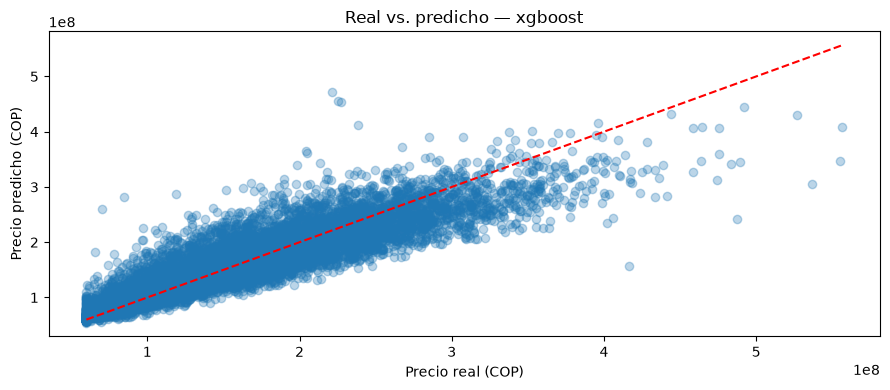

In [20]:
y_pred_mejor = mejor_modelo.predict(X_test_proc)

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred_mejor, alpha=0.3)
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, color="red", linestyle="--")
ax.set_xlabel("Precio real (COP)")
ax.set_ylabel("Precio predicho (COP)")
ax.set_title(f"Real vs. predicho — {mejor_nombre}")
plt.tight_layout()
plt.show()